## Google's page ranking mechanism

To make the simulation interesting, we do not use a toy irreversible ergodic Markov chain, instead we use one that is associated to how page ranking mechanism work. To explain it briefly, every node represent a website, and each transition represent the probability that a user goes from a starting website to the target website by clicking on a link present in the starting website. However, there is also some probability that the user opens a new tab and hence goes to a new website without clicking a link present in the starting website, to account for this, there is the so called damping factor $\alpha$. The page rank kernel is obtained as follow:

$\\ P = \alpha S + (1 - \alpha)\frac{1}{n}\mathbf{11^T} \\$

$S$ is the link following transition matrix obtained by a web bot that scrapes HTML files of a website and counts all the links.

$\alpha \in [0, 1]$ is the damping factor, i.e, the probability that the user do not open a new tab but follows a link inside the already opened tab.

$n$ is the number of nodes, i.e, websites.

$\mathbf{1}$ is the matrix where all entries are 1.

Also, in the literature, a node that represents a website with no links is called a dangling node.

We present therefore a full implementation, where the only inputs are the number of nodes, the damping factor, which by default is set to $0.85$ and the sparcity of the initial $S$. 


In [120]:
import numpy as np
import networkx as nx

def validate_power_of_two_dimension(dim):
    if not isinstance(dim, int):
        raise TypeError(f"dim must be an integer, got {type(dim)}.")

    if dim <= 0:
        raise ValueError(f"dim must be positive, got dim = {dim}.")

    if dim & (dim - 1) != 0:
        raise ValueError(
            f"dim must be a power of 2 for the current quantum implementation. "
            f"Got dim = {dim}."
        )

    return int(np.log2(dim))


def validate_markov_kernel(P, dim, tol=1e-12):
    P = np.asarray(P, dtype=float)

    if P.shape != (dim, dim):
        raise ValueError(
            f"P must have shape ({dim}, {dim}), but got shape {P.shape}."
        )

    if not np.all(np.isfinite(P)):
        raise ValueError("P contains NaN or infinite values.")

    if np.any(P < -tol):
        raise ValueError("P contains negative entries.")

    P = np.maximum(P, 0.0)

    row_sums = P.sum(axis=1)

    if not np.allclose(row_sums, np.ones(dim), atol=tol):
        raise ValueError(
            "Rows of P do not sum to 1. "
            f"Row sums are: {row_sums}"
        )

    P = P / P.sum(axis=1, keepdims=True)

    return P


dim = 8
alpha = 0.85

n_state_qubits = validate_power_of_two_dimension(dim)

if not (0 <= alpha <= 1):
    raise ValueError(f"alpha must be between 0 and 1, got alpha = {alpha}.")

G = nx.gnp_random_graph(
    n=dim,
    p=0.35,
    seed=7,
    directed=True
)

P = np.asarray(
    nx.google_matrix(
        G,
        alpha=alpha,
        nodelist=list(range(dim))
    ),
    dtype=float
)

P = validate_markov_kernel(P, dim)

dangling_nodes = [i for i in range(dim) if G.out_degree(i) == 0]

print(P)
print("Shape:", P.shape)
print("Rows sum to 1:", np.allclose(P.sum(axis=1), np.ones(dim)))
print("All entries positive:", np.all(P > 0))
print("Minimum transition probability:", P.min())
print("Number of state qubits:", n_state_qubits)
print("Dangling nodes:", dangling_nodes)
print("Number of dangling nodes:", len(dangling_nodes))
print("P passed all checks.")

[[0.01875    0.23125    0.23125    0.01875    0.23125    0.01875
  0.01875    0.23125   ]
 [0.01875    0.01875    0.30208333 0.01875    0.30208333 0.30208333
  0.01875    0.01875   ]
 [0.44375    0.44375    0.01875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.18875    0.01875    0.18875    0.01875    0.18875    0.18875
  0.18875    0.01875   ]
 [0.30208333 0.01875    0.01875    0.01875    0.01875    0.01875
  0.30208333 0.30208333]
 [0.30208333 0.01875    0.01875    0.30208333 0.01875    0.01875
  0.01875    0.30208333]
 [0.01875    0.01875    0.86875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.30208333 0.01875    0.30208333 0.01875    0.01875    0.30208333
  0.01875    0.01875   ]]
Shape: (8, 8)
Rows sum to 1: True
All entries positive: True
Minimum transition probability: 0.018750000000000003
Number of state qubits: 3
Dangling nodes: []
Number of dangling nodes: 0
P passed all checks.


## Non reversible markov chain

We make here a complete automated implementation of a generic non reversible ergodic Markov chain. The notebook only take as input the dimension, which must be a power of 2, and the kernel. It then computes the full quantum circtuit and make a simulation to calculate the total variational distance between the theoretical stationary distribution and the obtained stationary distribution from the circuit.

In [121]:
from numpy.polynomial import Chebyshev, Polynomial, chebyshev
import matplotlib.pyplot as plt

from scipy.linalg import null_space, block_diag
from scipy.optimize import minimize
from scipy.signal import fftconvolve

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit.providers.fake_provider import GenericBackendV2

# Basis

eye = np.identity(dim)
basis = np.asarray([row.reshape(-1,1) for row in eye])

eigvals, eigvecs = np.linalg.eig(P.T)

# Finding the index of the eigenvalue equal to 1

index = np.where(np.isclose(eigvals, 1))[0][0]

# Retreiving the stationary distribution and normalizing it

pi = np.real(eigvecs[:, index])

if np.sum(pi) < 0:
    pi = -pi

pi = pi / np.sum(pi)

# defining pi state

pi_state = np.sqrt(pi).reshape(-1, 1)

print(f"Markov kernel loaded: \n{P}")

print(f"Stationary distribution: {pi}")
print(f"State of the stationary distribution: {pi_state}")

# Non reversability check

reversible = True

for i in range(P.shape[0]):
    for j in range(P.shape[0]):

        if not np.allclose(pi[i]*P[i, j],  pi[j]*P[j, i]):
            reversible = False
            break
    
    if not reversible:
        break

assert not reversible, "Chain is reversible"
print("The chain is not reversible")

# Computing the time reversal chain

P_rev = np.zeros((dim, dim))

for i in range(P.shape[0]):
    for j in range(P.shape[0]):

        P_rev[i][j] = (pi[j]/pi[i]) * P[j][i]

print(f"Time reversal chain: \n{P_rev}")

Markov kernel loaded: 
[[0.01875    0.23125    0.23125    0.01875    0.23125    0.01875
  0.01875    0.23125   ]
 [0.01875    0.01875    0.30208333 0.01875    0.30208333 0.30208333
  0.01875    0.01875   ]
 [0.44375    0.44375    0.01875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.18875    0.01875    0.18875    0.01875    0.18875    0.18875
  0.18875    0.01875   ]
 [0.30208333 0.01875    0.01875    0.01875    0.01875    0.01875
  0.30208333 0.30208333]
 [0.30208333 0.01875    0.01875    0.30208333 0.01875    0.01875
  0.01875    0.30208333]
 [0.01875    0.01875    0.86875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.30208333 0.01875    0.30208333 0.01875    0.01875    0.30208333
  0.01875    0.01875   ]]
Stationary distribution: [0.20754276 0.14695565 0.19788896 0.04814735 0.11267532 0.10375536
 0.05885972 0.12417486]
State of the stationary distribution: [[0.45556862]
 [0.38334795]
 [0.44484712]
 [0.21942505]
 [0.33567145]
 [0.32211079]
 [0.24261023

## Main operators

The goal is to implement the following circuit:

$\\ (\bra{01} \otimes \square_P^\dagger)G(\ket{01} \otimes \square_P) \\$
To do so, the first step is to define the following operators:
$\\
    \square_P = \sum_{x \in S}\ket{x}\ket{P(x, .)}\bra{x} \\
    \square_{P^*} = \sum_{x \in S}\ket{x}\ket{P^*(x, .)}\bra{x} \\
    S = \sum_{x, y \in S} \ket{x, y}\bra{y, x}
$

And $G$ is obtained via GQSP. This time the chebyschev polynomial is applied to a different walk operator which is:

$\\ W = (2\widehat{\square}\widehat{\square}^\dagger - I)\widehat{S} \\$

where

$\\ \widehat{\square} = (\ket{0}\bra{0} \otimes \square_{P^*} + \ket{1}\bra{1} \otimes \square_P) \\ 
\widehat{S} = (\ket{0}\bra{0} \otimes S + \ket{1}\bra{1} \otimes S^\dagger)(X \otimes I)$


In [122]:
# Defining the isometries

square = np.zeros((dim * dim, dim))
square_rev = np.zeros((dim * dim, dim)) # both have dim = 16 x 4

for x in range(dim):
    for y in range(dim):
        square += np.sqrt(P[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T
        square_rev += np.sqrt(P_rev[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T

# Defining the swap operator

swap = np.zeros(((dim * dim), (dim * dim))) # dim 16 x 16

for x in range(dim):
    for y in range(dim):
        swap += np.kron(basis[x], basis[y]) @ np.kron(basis[y].conj().T, basis[x].conj().T)

# Defining hermitized square

proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
proj_1 = np.array([[0, 0], [0, 1]], dtype=complex) # both have dim 2 x 2

square_herm = np.kron(proj_0, square_rev) + np.kron(proj_1, square) # dim 32 x 8

# Defining hermitized swap

X_gate = np.array([[0, 1], [1, 0]], dtype=complex) # dim 2 x 2

I_space = np.eye(dim * dim, dtype=complex) # dim 16 x 16

swap_herm = (np.kron(proj_0, swap) + np.kron(proj_1, swap))@(np.kron(X_gate, I_space)) # dim 32 x 32

# Defining the hermitized walk operator

I_space_large = np.eye(dim*dim*2) # 32 x 32

W_herm = (2*square_herm@square_herm.conj().T - I_space_large)@swap_herm # dim 32 x 32

print(f"Walk operator: {W_herm}")

# Sanity checks

assert np.allclose(W_herm @ W_herm.conj().T, np.eye(dim * dim * 2)), "Critical error, walk operator is not unitary"

print("Walk operator is unitary")

print(f"Number of non zero elements: {np.count_nonzero(W_herm)}")


Walk operator: [[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
Walk operator is unitary
Number of non zero elements: 1024


## Curved discriminant

The curved discriminant is defined as: $D = \square_{P^*}^\dagger S \square_P \\$ where each element is:

$D(x, y) = \sqrt{P^*(x, y)P(y, x)}$

Thus, we define it in the two ways and then do a sanity check for their equivalence.


In [123]:
# Defining the curved discriminant as the SPUE

D = square_rev.conj().T @ swap @ square # dim 4 x 4

# Sanity check for the equivalence

D_check = np.zeros((dim, dim))

for x in range(dim):
    for y in range(dim):

        D_check[x][y] = np.sqrt(P_rev[x, y]*P[y, x])

assert np.allclose(D, D_check), "Critical error in the definition of the curved discriminant"

print("Curved discriminant correctly loaded")
print(D)



Curved discriminant correctly loaded
[[0.01875    0.01577759 0.43330665 0.09091161 0.22258063 0.21358868
  0.0099852  0.23366293]
 [0.27481624 0.01875    0.51493927 0.01073234 0.01641809 0.01575482
  0.01186635 0.01723554]
 [0.23682348 0.26032095 0.01875    0.09310272 0.01414832 0.01357675
  0.47379791 0.23929456]
 [0.03892861 0.03275731 0.03801245 0.01875    0.02868332 0.4434512
  0.02073119 0.03011147]
 [0.31384928 0.3449892  0.02484836 0.12338398 0.01875    0.01799253
  0.01355177 0.01968356]
 [0.02651855 0.35951303 0.02589446 0.12857836 0.01953936 0.01875
  0.01412229 0.33047479]
 [0.03520837 0.02962684 0.03437977 0.170712   0.41795744 0.02489416
  0.01875    0.02723385]
 [0.29896386 0.02039753 0.02366983 0.01167537 0.28775595 0.27613102
  0.01290903 0.01875   ]]


## Spectral gap of the curved discriminant

A property of the curved discriminant is that it has both left and right singular vectors associated with singular value $1$ that exactly coincide with the sought probability distribution $\ket{\pi}. \\$
Before defining the chebyshev polynomial a crucial point is to find the spectral gap of the curved discriminant. Remember that the spectral gap is defined as $\delta = 1 - \sigma_2(D)$  where $\sigma_2(D)$ is the second largest singular value of $D$. 

In [124]:
# SVD of D

left_sv, svalues, right_sv = np.linalg.svd(D)

spectral_gap = 1 - svalues[1]

assert np.isclose(svalues[0], 1), print("Error: leading sv of D is not 1!")
print(f"Leading singular value of the curved discriminant is {svalues[0]}")
print(f"Second largest singular value: {svalues[1]}")
print(f"Spectral gap (The higher the better!): {spectral_gap}")

# Checking that both first right and left singular vector coincide with the pi state

left_vector = left_sv[:, 0]

right_vector = right_sv[0, :].conj()

# Making them positive since the pi state is positive

if np.real(left_vector[0]) < 0:
    left_vector = -left_vector
if np.real(right_vector[0]) < 0:
    right_vector = -right_vector

assert np.allclose(left_vector, right_vector), "Error: right and left singular error are not equal"
print("Right and left singular vector are equal")

assert np.allclose(pi_state.flatten(), right_vector) and np.allclose(pi_state.flatten(), left_vector), "Error: right or left singular vector do not match pi state"
print("Right and left singular vector match pi state")



Leading singular value of the curved discriminant is 0.9999999999999999
Second largest singular value: 0.6797460415639235
Spectral gap (The higher the better!): 0.3202539584360765
Right and left singular vector are equal
Right and left singular vector match pi state


## Chebyshev polynomial

We now define the polynomial that will be applied in GQSP to $W$. We set $\epsilon=0.01$. In order to find the degree of the chebyshev polynomial, we use the well known extremely useful formula: 
$ \\ d = \frac{\operatorname{arccosh}(\frac{1}{\epsilon})}{\operatorname{arccosh}(\frac{1}{1 - \delta})}$

In [125]:
epsilon = 0.01

d_raw = np.arccosh(1 / epsilon) / np.arccosh(1 / (1 - spectral_gap))
d = int(np.ceil(d_raw))

print(f"Raw degree {d_raw}")

# Since GQSVT applies an even polynomial, we need to make it even

if d % 2 != 0:
    d += 1

print(f"Degree of chebyshev polynomial is: {d}")

Raw degree 5.659672337965932
Degree of chebyshev polynomial is: 6


It is now time to define the polynomial which will be applied by GQSP. We do the following design choice: $\nu(x) = \epsilon T_d(\alpha x)$.

To find $\alpha$ we set the following contraint: $\nu(1) = 1$ since for the algorithm to work it must output $1$ if the singular value is 1. This leads to $\alpha = \cosh(\frac{\operatorname{arccosh}{(\frac{1}{\epsilon})}}{d}). \\$ Also, the design guarantees that all other garbage singular values are bounded by $\epsilon$ because $\alpha x_{garbage} \leq 1$.

In [126]:
alpha = np.cosh(np.arccosh(1 / epsilon) / d) 

# New spectral gap
delta_d = 1 - 1 / alpha 

assert delta_d <= spectral_gap + 1e-12, ("The chosen degree is not large enough: delta_d > spectral_gap.")

# Building the polynomial

x_poly = Polynomial([0.0, alpha]) # we build alpha * x
nu_power = epsilon * Chebyshev.basis(d)(x_poly) # epsilon * T_d(alpha * x)

# Convert to chebyshex basis
nu = nu_power.convert(kind=Chebyshev)

# Coefficients that nu and the signal polynomial share a1, ...
coef = nu.coef

print(coef)


[0.25271494 0.         0.42442907 0.         0.24228506 0.
 0.08057093]


## Quantum circuit

All the elements are now present to build the circuit. First we build the gates, some of which are not immediate and need unitary expansion, like the isometries.

In [127]:
# Function to build V_x such that it is unitary and its first column is |psi_x>
def complete_vector_to_unitary(v, atol=1e-12):
    """
    Given a normalized vector v in C^n, build a unitary U
    whose first column is v.
    """
    v = np.asarray(v, dtype=complex).reshape(-1, 1)
    n = v.shape[0]

    norm = np.linalg.norm(v)
    assert np.allclose(norm, 1.0, atol=atol), f"Input vector is not normalized. Norm = {norm}"

    # Find an orthonormal basis of the orthogonal complement of v.
    # This returns an n x (n-1) matrix Q such that v^dagger Q = 0.
    complement = null_space(v.conj().T)

    U = np.hstack([v, complement])

    assert np.allclose(U.conj().T @ U, np.eye(n), atol=atol), "Completion failed: U is not unitary."

    assert np.allclose(U[:, 0], v[:, 0], atol=atol), "First column is not the requested vector."

    return U


# Function to build V, controlled V_x
def build_controlled_unitary_extension(P, atol=1e-12):
    """
    Build V = sum_x |x><x| tensor V_x,
    where V_x |0> = sum_y sqrt(P[x,y]) |y>.
    """
    P = np.asarray(P, dtype=float)
    dim = P.shape[0]

    assert P.shape == (dim, dim), "P must be square."

    assert np.allclose(P.sum(axis=1), 1.0, atol=atol), "Rows of P must sum to 1."

    blocks = []

    for x in range(dim):
        psi_x = np.sqrt(P[x, :]).astype(complex)
        V_x = complete_vector_to_unitary(psi_x, atol=atol)
        blocks.append(V_x)

    V = block_diag(*blocks)

    assert np.allclose(V.conj().T @ V, np.eye(dim * dim), atol=atol), "V is not unitary."

    return V, blocks

In [128]:
V, V_Blocks = build_controlled_unitary_extension(P)

print(f"Shape of V: {V.shape}")
print(f"\nUnitary extension of square:\n{V}")

for x in range(dim):
    input_col = dim * x + 0
    assert np.allclose(V[:, input_col], square[:, x])

print("V correctly extends square.")

Shape of V: (64, 64)

Unitary extension of square:
[[ 0.13693064+0.j -0.4808846 -0.j -0.4808846 -0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.4808846 +0.j  0.79660149-0.j -0.20339851-0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.4808846 +0.j -0.20339851-0.j  0.79660149-0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 ...
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.80505987-0.j
  -0.04856669-0.j -0.04856669-0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ... -0.04856669-0.j
   0.98790027-0.j -0.01209973-0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ... -0.04856669-0.j
  -0.01209973-0.j  0.98790027-0.j]]
V correctly extends square.


In [129]:
# Ordering for qiskit
def math_to_qiskit_permutation_xy(dim):
    """
    Math order:    |x>|y>, index dim*x + y
    Qiskit order:  [qx0, qx1, qy0, qy1], index x + dim*y
    """
    N = dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for x_state in range(dim):
        for y_state in range(dim):
            math_index = dim * x_state + y_state
            qiskit_index = x_state + dim * y_state
            Perm[qiskit_index, math_index] = 1.0

    return Perm


def math_to_qiskit_permutation_hxy(dim):
    """
    Math order:    |h>|x>|y>, index h*dim*dim + dim*x + y
    Qiskit order:  [qx0, qx1, qy0, qy1, qh], index x + dim*y + dim*dim*h
    """
    N = 2 * dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for h_state in range(2):
        for x_state in range(dim):
            for y_state in range(dim):
                math_index = h_state * dim * dim + dim * x_state + y_state
                qiskit_index = x_state + dim * y_state + dim * dim * h_state
                Perm[qiskit_index, math_index] = 1.0

    return Perm

perm_xy = math_to_qiskit_permutation_xy(dim)
print(f"Permutation to go from big-endian to little-endian:\n{perm_xy.real}")
V_qiskit = perm_xy @ V @ perm_xy.conj().T

assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(dim*dim)), "V is not unitary."
print(f"\nV with little-endian ordering:\n{V_qiskit}")

Permutation to go from big-endian to little-endian:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

V with little-endian ordering:
[[0.13693064+0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.13693064+0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.66614563+0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 ...
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.80505987+0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.98350823+0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.98790027+0.j]]


We can now start the implementation, remember that we want to implement the following:

$(\bra{01} \otimes \square_P^\dagger) G (\ket{01} \otimes \square_P) = \ket{\pi}\bra{\pi}$

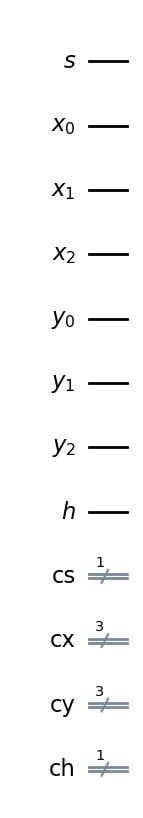

In [130]:
# Quantum registers, fully automated

assert 2**n_state_qubits== dim, "dimension of the kernel matrix must be a power of 2"

qs = QuantumRegister(1, "s") # Ancillary qubit for GQSP
qx = QuantumRegister(n_state_qubits, "x") # Register for the markov chain state
qy = QuantumRegister(n_state_qubits, "y") # Register for the markov chain target state
qh = QuantumRegister(1, "h") # New hermitianization qubit

# Classical registers

cs = ClassicalRegister(1, "cs")
cx = ClassicalRegister(n_state_qubits, "cx")
cy = ClassicalRegister(n_state_qubits, "cy")
ch = ClassicalRegister(1, "ch")

qc = QuantumCircuit(qs, qx, qy, qh, cs, cx, cy, ch)

qc.draw("mpl")

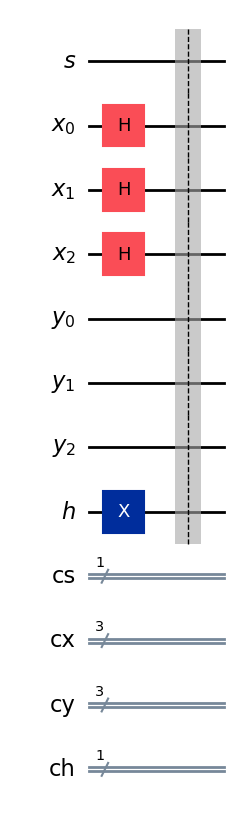

In [131]:
# Initialization

for q in qx:
    qc.h(q)

qc.x(qh[0])

qc.barrier()
qc.draw("mpl")

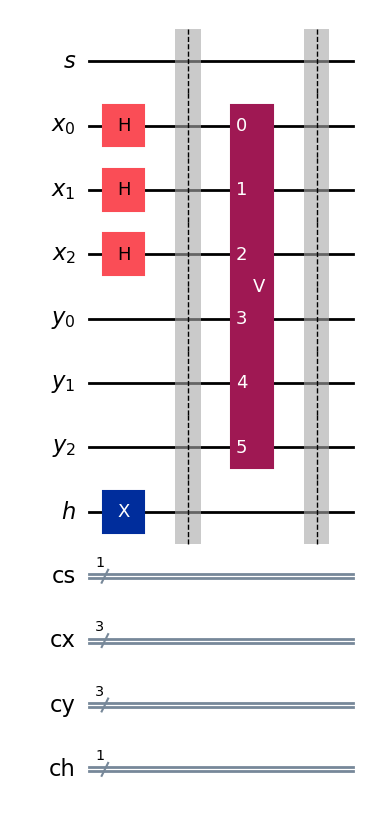

In [132]:
# Applying the first isometry

V_gate = UnitaryGate(V_qiskit, label="V")
qc.append(V_gate, list(qx) + list(qy))

qc.barrier()
qc.draw("mpl")

Here we apply the big gate, i.e, the GQSP, which this time will be applied on the hermitianized walk operator.

In [133]:
# Function simply implement the algorithm explained in the paper of GQSP
def find_Q_polynomial(P_coefs):
    """
    Calculates the coefficients of polynomial Q given polynomial P 
    for Generalized Quantum Signal Processing (GQSP).
    
    Args:
        P_coefs (numpy.ndarray): Complex coefficients of P [a_0, a_1, ..., a_d]
        
    Returns:
        numpy.ndarray: Complex coefficients of Q [b_0, b_1, ..., b_d]
    """
    a = np.array(P_coefs, dtype=complex)
    d = len(a) - 1
    
    a_rev_conj = np.conjugate(a[::-1])
    a_conv = fftconvolve(a, a_rev_conj)
    
    delta = np.zeros(2*d + 1, dtype=complex)
    delta[d] = 1.0
    
    target_b_conv = delta - a_conv
    
    def objective(b_concat):

        b = b_concat[:d+1] + 1j * b_concat[d+1:]
        
        # Compute b * reverse(b)*
        b_rev_conj = np.conjugate(b[::-1])
        b_conv = fftconvolve(b, b_rev_conj)
        
        # L2 norm squared of the difference
        diff = b_conv - target_b_conv
        return np.sum(np.abs(diff)**2)

    np.random.seed(42) # Fixed seed for reproducibility 
    b_init = np.random.randn(d+1) + 1j * np.random.randn(d+1)
    
    x0 = np.concatenate([np.real(b_init), np.imag(b_init)])
    
    result = minimize(objective, x0, method='L-BFGS-B', 
                      options={'maxiter': 50000, 'ftol': 1e-12})
    
    if not result.success:
        print(f"Warning: Optimization may not have fully converged. Message: {result.message}")
        print(f"Final objective value: {result.fun}")
        
    b_opt = result.x[:d+1] + 1j * result.x[d+1:]
    
    return b_opt

P_coefficients = np.array(coef)

Q_coefficients = find_Q_polynomial(P_coefficients)
print("Coefficients of P:")
print(np.round(P_coefficients, 4))
print("\nFound Coefficients for Q:")
print(np.round(Q_coefficients, 4))

Coefficients of P:
[0.2527 0.     0.4244 0.     0.2423 0.     0.0806]

Found Coefficients for Q:
[-0.0295+0.0596j  0.073 +0.0857j  0.0733+0.2506j  0.4523-0.0587j
 -0.1826-0.0288j -0.5184-0.0276j  0.1358-0.2746j]


In [134]:
# This function computes the rotation angles given P and Q according to the algorithm given in the GQSP paper.
def compute_rotation_angles(S, d):
    """
    Computes the rotation angles for GQSP.
    
    Args:
        S (numpy.ndarray): 2 x (d+1) complex matrix where the first row 
                           contains the coefficients of P and the second row 
                           contains the coefficients of Q.
        d (int): Degree of the polynomials.
        
    Returns:
        tuple: (theta_list, phi_list, lambda_val)
               where theta_list and phi_list are ordered from index 0 to d.
    """
    theta_list = []
    phi_list = []
    
    # Make a copy to avoid mutating the original input
    current_S = np.array(S, dtype=complex)
    
    # Process from degree d down to 1
    for current_d in range(d, 0, -1):
        a_d = current_S[0][current_d]
        b_d = current_S[1][current_d]
        
        abs_a = np.abs(a_d)
        abs_b = np.abs(b_d)
        
        theta_d = np.arctan2(abs_b, abs_a)
        if abs_b == 0:
            phi_d = np.angle(a_d)
        elif abs_a == 0:
            phi_d = -np.angle(b_d)
        else:
            phi_d = np.angle(a_d * np.conj(b_d))
            
        theta_list.append(theta_d)
        phi_list.append(phi_d)
        
        exp_neg_i_phi = np.exp(-1j * phi_d)
        cos_t = np.cos(theta_d)
        sin_t = np.sin(theta_d)
        
        R_dagger = np.array([
            [exp_neg_i_phi * cos_t,  sin_t],
            [exp_neg_i_phi * sin_t, -cos_t]
        ])
        
        S_temp = R_dagger @ current_S
        
        P_hat = S_temp[0][1:]  
        
        Q_hat = S_temp[1][:-1] 
        
        current_S = np.array([P_hat, Q_hat])
        
    a_0 = current_S[0][0]
    b_0 = current_S[1][0]
    
    abs_a0 = np.abs(a_0)
    abs_b0 = np.abs(b_0)
    
    theta_0 = np.arctan2(abs_b0, abs_a0)
    
    if abs_b0 == 0:
        phi_0 = np.angle(a_0)
        lambda_val = 0.0
    elif abs_a0 == 0:
        phi_0 = -np.angle(b_0)
        lambda_val = np.angle(b_0)
    else:
        phi_0 = np.angle(a_0 * np.conj(b_0))
        lambda_val = np.angle(b_0)
        
    theta_list.append(theta_0)
    phi_list.append(phi_0)
    
    # Reverse the lists because we processed from d down to 0, 
    # but the circuit requires them from 0 up to d.
    theta_list.reverse()
    phi_list.reverse()
    
    return theta_list, phi_list, lambda_val

In [135]:
# Build S first

S = np.vstack([P_coefficients, Q_coefficients])

# Computing the angles

theta_list, phi_list, lambda_val = compute_rotation_angles(S, d)

print(f"Theta list: {theta_list}")
print(f"Phi list: {phi_list}")
print(f"lambda_val: {lambda_val}")

Theta list: [np.float64(0.6897238467991991), np.float64(0.6938458780242985), np.float64(0.5128679728005555), np.float64(0.685381849674437), np.float64(0.5396651881606117), np.float64(0.3949039737913727), np.float64(1.3136399545505726)]
Phi list: [np.float64(1.9769401893246878), np.float64(3.0954909295018775), np.float64(0.8214567720768216), np.float64(1.472232667984862), np.float64(-3.0599398899275947), np.float64(-1.1647566721871074), np.float64(1.1116261168723582)]
lambda_val: 2.030135193533681


As the last notebook, we compute the rotation and controlled gate of GQSP.

In [136]:
# Defining the rotation gate, since it has parameters it needs to be 
# defined as a subclass of the Gate class

def RotationGate(theta, phi, lam):
    # Computes the GQSP rotation matrix and returns it as a Qiskit UnitaryGate 
    U = np.array([
        [
            np.exp(1j * (lam + phi)) * np.cos(theta),
            np.exp(1j * phi) * np.sin(theta)
        ],
        [
            np.exp(1j * lam) * np.sin(theta),
            -np.cos(theta)
        ]
    ], dtype=complex)
    
    # Wrap and return the matrix as a UnitaryGate
    return UnitaryGate(U, label=r"$R_{GQSP}$")

perm_hxy = math_to_qiskit_permutation_hxy(dim)
W_qiskit = perm_hxy @ W_herm @ perm_hxy.conj().T

assert np.allclose(W_qiskit.conj().T @ W_qiskit, np.eye(2 * dim * dim)), "W_qiskit not unitary"
        
# Defining the A gate
W_gate = UnitaryGate(W_qiskit, label="W")

A = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")

Theta list: [np.float64(0.6897238467991991), np.float64(0.6938458780242985), np.float64(0.5128679728005555), np.float64(0.685381849674437), np.float64(0.5396651881606117), np.float64(0.3949039737913727), np.float64(1.3136399545505726)]
Phi list : [np.float64(1.9769401893246878), np.float64(3.0954909295018775), np.float64(0.8214567720768216), np.float64(1.472232667984862), np.float64(-3.0599398899275947), np.float64(-1.1647566721871074), np.float64(1.1116261168723582)]
Lambda: 2.030135193533681


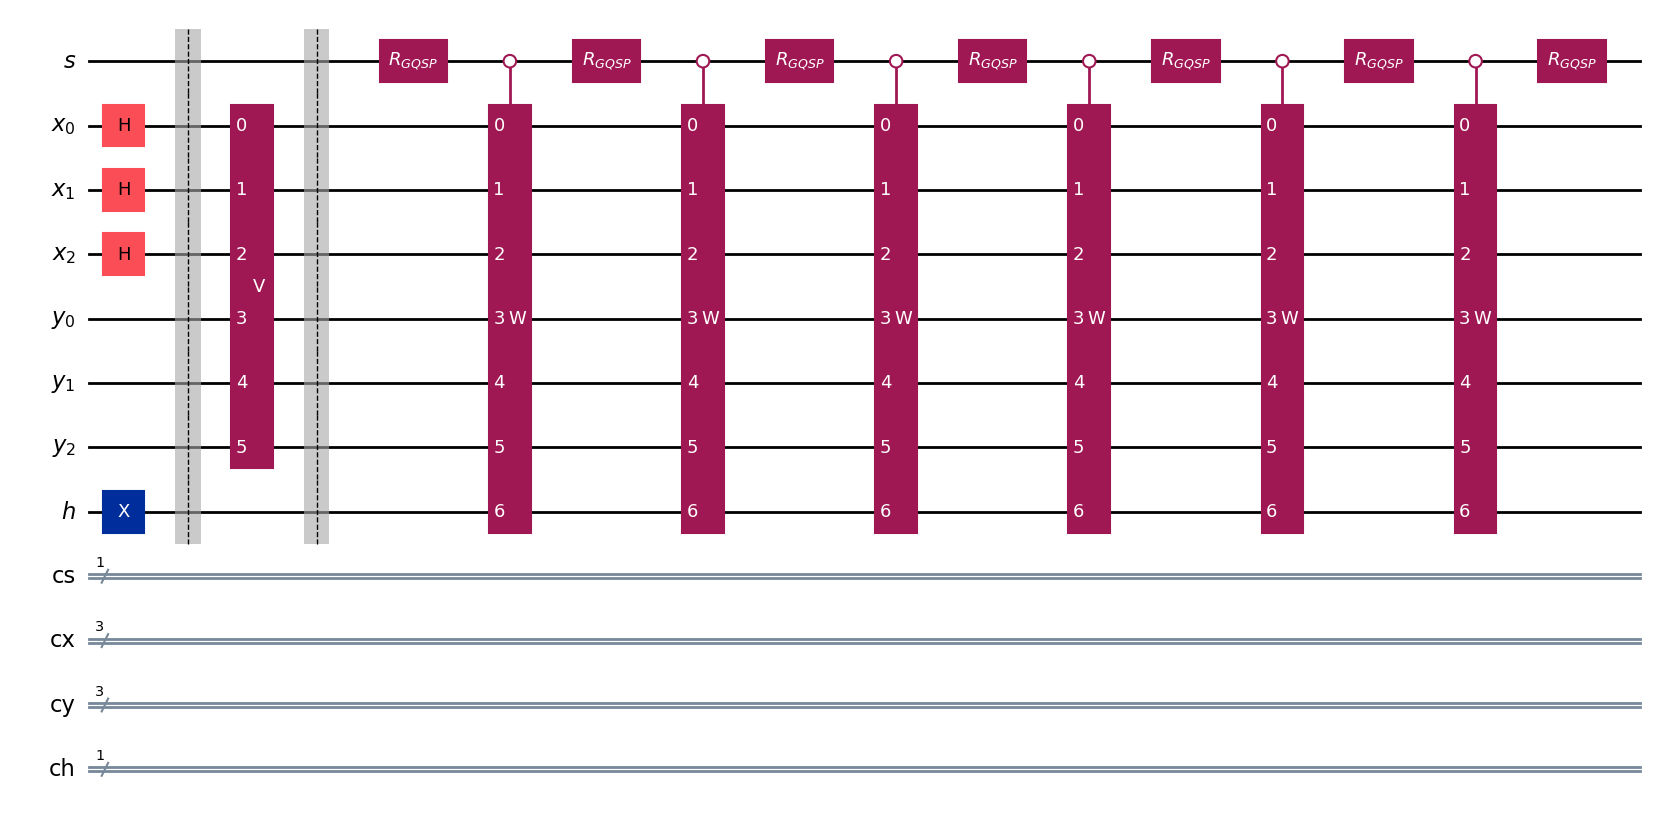

In [137]:
# Creating the gates
for index, angle_theta in enumerate(theta_list):

    angle_phi = phi_list[index]

    if index == 0:
        R_gate = RotationGate(angle_theta, angle_phi, lambda_val)
    else:
        R_gate = RotationGate(angle_theta, angle_phi, 0)
        qc.append(A, list(qs) + list(qx) + list(qy) + list(qh))

    qc.append(R_gate, qs)

print(f"Theta list: {theta_list}")
print(f"Phi list : {phi_list}")
print(f"Lambda: {lambda_val}")


qc.draw("mpl")


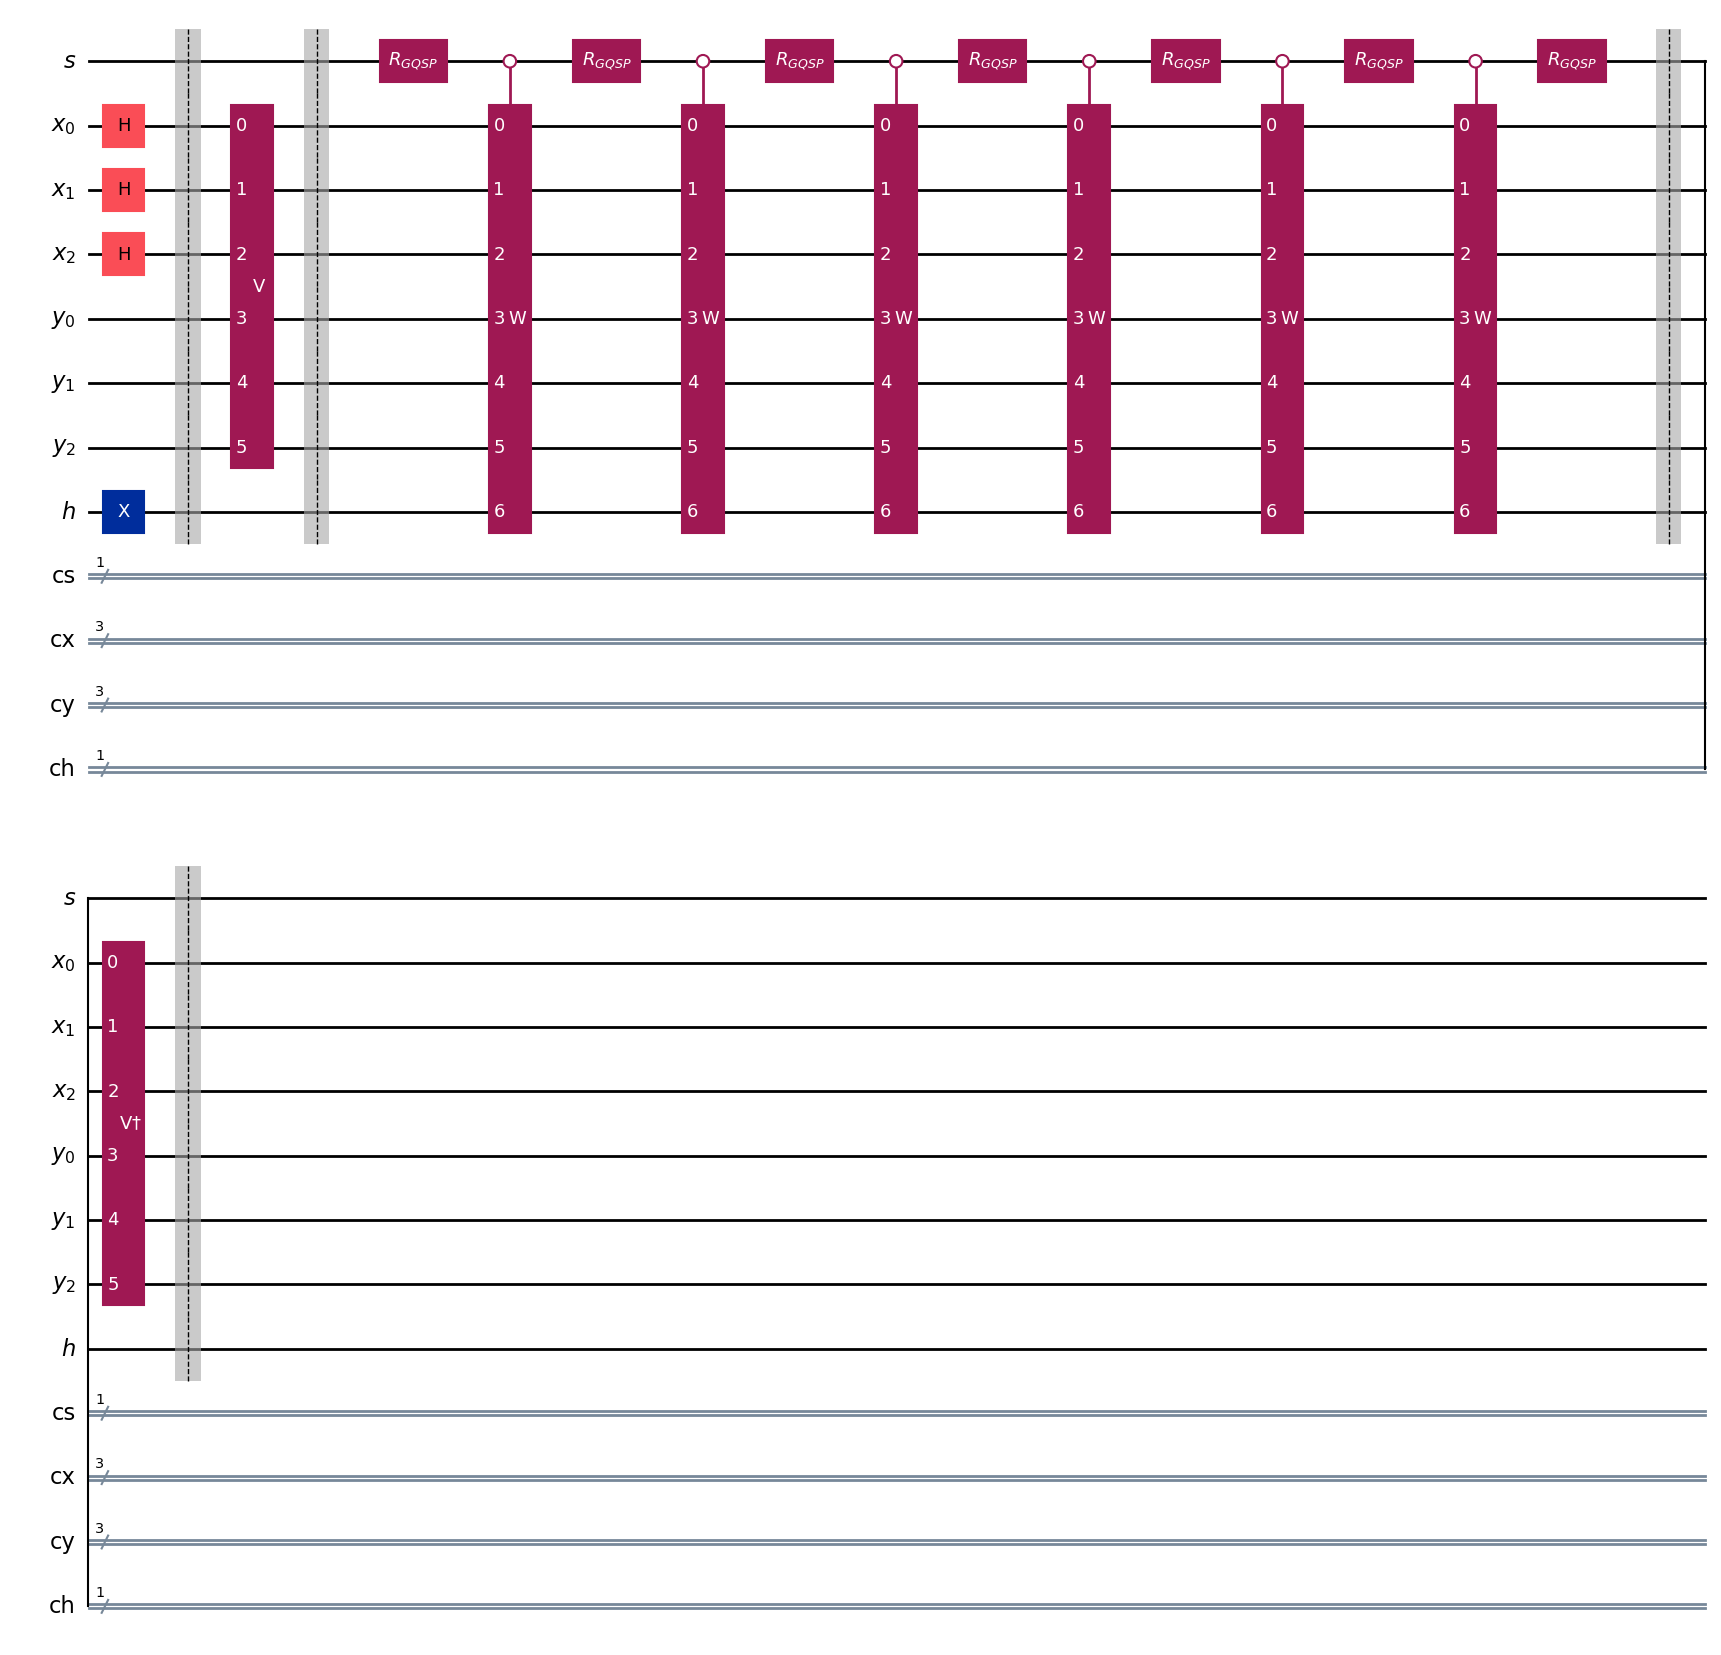

In [138]:
# Creating square dagger
qc.barrier()
V_gate_dagger = UnitaryGate(V_qiskit.conj().T, label=r"V$\dagger$")

qc.append(V_gate_dagger, list(qx) + list(qy))
qc.barrier()

qc.draw("mpl")

## Measurements

We now perform the measurements

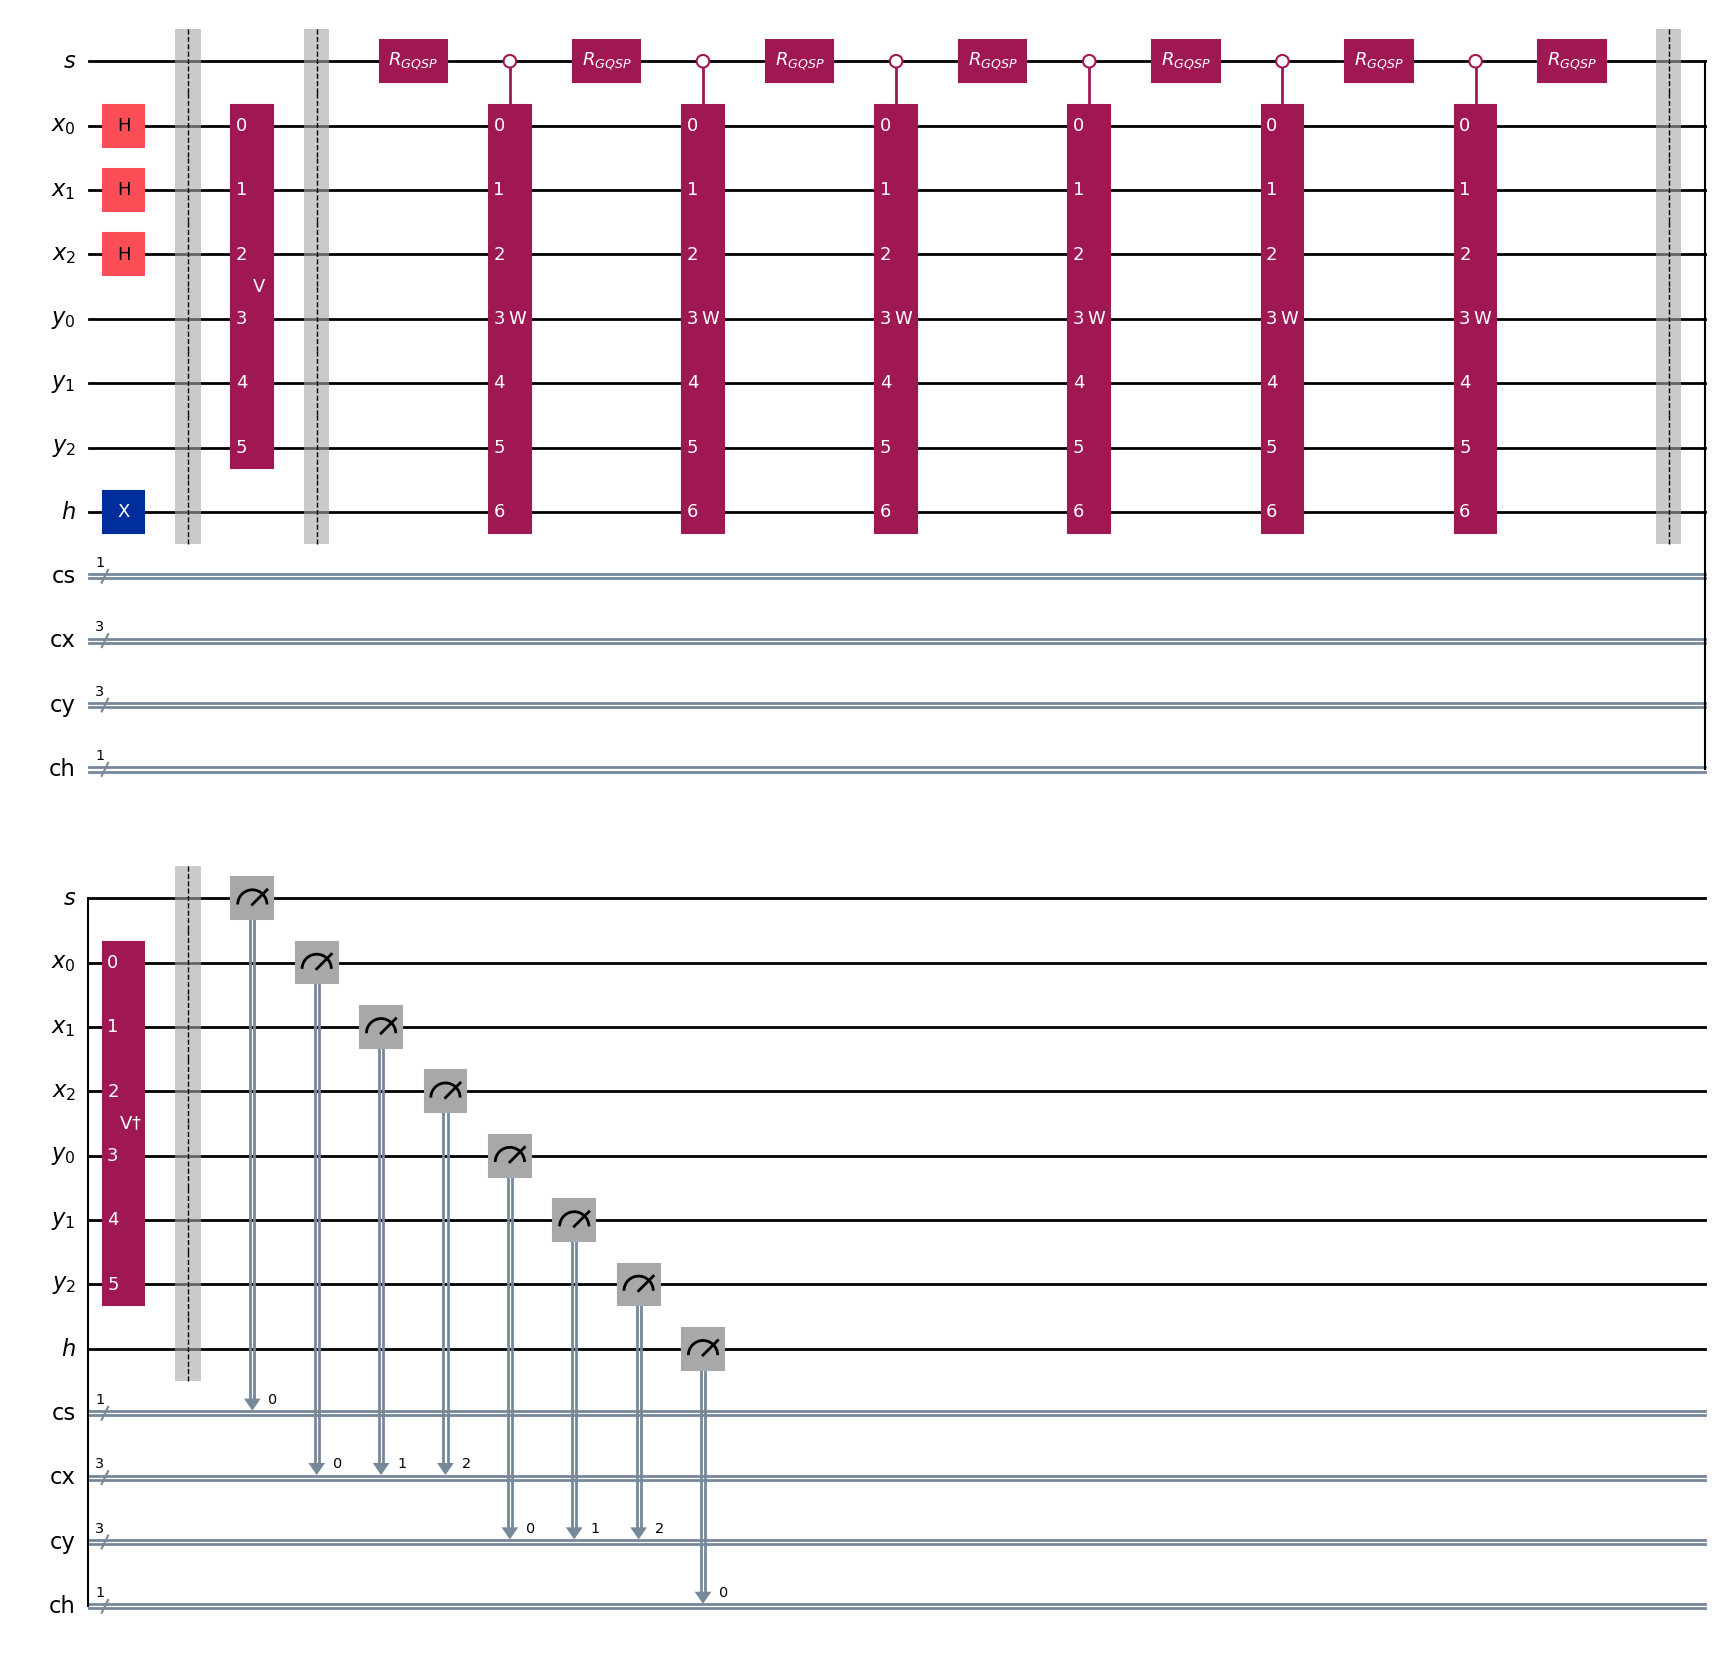

In [139]:
qc.measure(qs, cs)
qc.measure(qx, cx)
qc.measure(qy, cy)
qc.measure(qh, ch)

qc.draw("mpl")

## Simulation and results

Original circuit depth: 17
Compiled circuit depth: 199258
Gate counts: OrderedDict({'cx': 100650, 'u': 98234, 'rz': 55631, 'u2': 8184, 'measure': 8, 'unitary': 7, 'u3': 7, 'barrier': 4, 'h': 3, 'x': 1})
Raw counts: {'1 011 000 1': 1, '1 100 001 1': 2, '1 111 000 1': 1, '1 101 100 1': 1, '1 101 010 1': 1, '1 110 010 1': 1, '1 110 000 0': 1, '0 001 011 1': 2, '0 111 001 1': 3, '1 001 111 1': 1, '1 010 000 0': 2, '1 010 111 1': 2, '0 111 110 1': 4, '0 000 110 1': 2, '1 001 000 0': 1, '1 000 010 1': 8, '0 110 010 1': 4, '0 100 000 1': 16, '1 101 111 1': 5, '1 100 011 1': 2, '0 101 011 1': 2, '1 000 000 1': 12, '0 010 110 1': 5, '0 011 010 1': 14, '1 011 101 0': 1, '1 000 110 0': 560, '1 000 000 0': 1958, '1 000 110 1': 2, '0 011 011 1': 5, '0 001 110 1': 2, '1 110 001 1': 3, '0 000 000 1': 14, '1 100 010 1': 1, '1 111 100 1': 3, '1 010 001 0': 1, '1 000 011 1': 29, '1 000 111 0': 1238, '0 111 100 1': 7, '1 101 001 1': 2, '0 000 001 1': 14, '0 011 001 1': 3, '1 110 100 1': 2, '0 000 010 1':

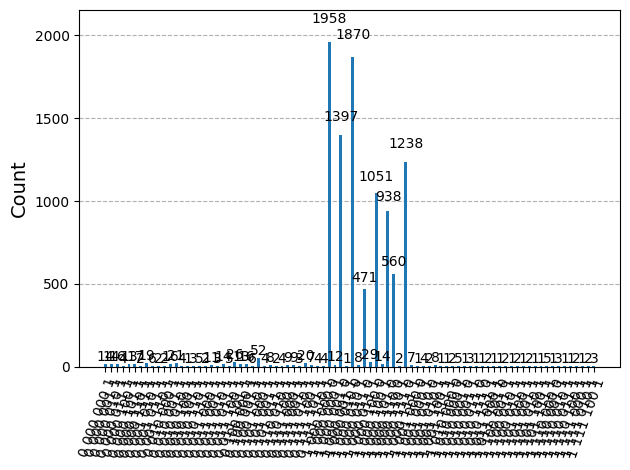

In [142]:
simulator_noiseless = AerSimulator() # Creating a virtual quantum computer

transpiled_qc = transpile(qc, simulator_noiseless) # Compiling the quantum circuit

print("Original circuit depth:", qc.depth())
print("Compiled circuit depth:", transpiled_qc.depth())
print("Gate counts:", transpiled_qc.count_ops())

# Running the circuit 10 000 times
trials = 10000
job = simulator_noiseless.run(transpiled_qc, shots=trials) # Running the simulation

results = job.result() # Obtaining the results from the simulation

raw_counts = results.get_counts()

print(f"Raw counts: {raw_counts}")
plot_histogram(raw_counts)

In [143]:
post_selected_counts = {}
successes = 0
zero_y = "0" * n_state_qubits 

for bitstring, count in raw_counts.items():
    # With registers (cs, cx, cy, ch), Qiskit usually prints groups
    # from last classical register to first:
    #     ch cy cx cs
    ch_val, cy_val, cx_val, cs_val = bitstring.split()

    # Correct post-selection:
    # s = 0  : GQSP signal ancilla success
    # h = 1  : bottom-right hermitianization block
    # y = all zero : projection back onto the isometry input subspace

    if cs_val == "0" and ch_val == "1" and cy_val == zero_y:
        post_selected_counts[cx_val] = post_selected_counts.get(cx_val, 0) + count
        successes += count

print(f"Post-selected counts: {post_selected_counts}")
print(f"Algorithm Success Rate: {(successes / trials) * 100:.2f}%\n")

probabilities = {
    bitstring: count / successes
    for bitstring, count in post_selected_counts.items()
}

print(f"Final probability distribution: {probabilities}\n")

# Convert Qiskit displayed bitstrings back to mathematical state indices.
# After the permutation fix, cx_bitstring already matches the mathematical state label.
measured = np.zeros(dim)

for cx_bitstring, prob in probabilities.items():
    i = int(cx_bitstring, 2)   # NO reverse
    measured[i] += prob

tvd = 0.5 * np.sum(np.abs(pi - measured))

print(f"Measured distribution ordered as states 0,1,2,3: {measured}")
print(f"Theoretical distribution: {pi}")
print(f"Total Variation Distance to theoretical distribution: {tvd:.4f}")

Post-selected counts: {'110': 560, '000': 1958, '111': 1238, '100': 1051, '001': 1397, '010': 1870, '101': 938, '011': 471}
Algorithm Success Rate: 94.83%

Final probability distribution: {'110': 0.05905304228619635, '000': 0.20647474427923654, '111': 0.13054940419698408, '100': 0.11082990614784351, '001': 0.14731625013181482, '010': 0.19719498049140569, '101': 0.09891384582937889, '011': 0.049667826637140144}

Measured distribution ordered as states 0,1,2,3: [0.20647474 0.14731625 0.19719498 0.04966783 0.11082991 0.09891385
 0.05905304 0.1305494 ]
Theoretical distribution: [0.20754276 0.14695565 0.19788896 0.04814735 0.11267532 0.10375536
 0.05885972 0.12417486]
Total Variation Distance to theoretical distribution: 0.0084


## Further analysis

As you have seen we are correctly able to sample from the distribution with the quantum algorithm, in a way that is quadratically faster than classically!